In [1]:
import os
from pathlib import Path

import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

In [2]:
style_path = os.environ["MPL_STYLE"]
print("matplotlib style:", style_path)
plt.style.use(style_path)

PLOTW, _ = plt.rcParams["figure.figsize"]
FORMAT = plt.rcParams["savefig.format"]
print(PLOTW, FORMAT)

matplotlib style: /ocean/projects/med220004p/clane2/ARFC/arfc-experiments/resources/clane.mplstyle
3.42 png


In [3]:
project_root = Path(os.environ["PROJECT_ROOT"])

hcp_fd_dir = project_root / "results/hcp_1200_rfmri_fd"
hcp_fd = pd.read_parquet(hcp_fd_dir / "hcp_1200_rfmri_fd.parquet")

# Only include 3T data and full runs.
hcp_fd = hcp_fd.query("mag == '3T' and n_frames == 1200")

print(hcp_fd.shape)
print(hcp_fd.iloc[:5, :8])

(4210, 11)
      sub    mod   task mag dir  n_frames   mean_fd  n_censor_frames
0  100206  rfMRI  REST1  3T  LR      1200  0.099991                4
1  100206  rfMRI  REST1  3T  RL      1200  0.105217                0
2  100206  rfMRI  REST2  3T  LR      1200  0.123617                4
3  100206  rfMRI  REST2  3T  RL      1200  0.106712                0
4  100307  rfMRI  REST1  3T  LR      1200  0.120536                0


In [4]:
hcp_fd_grouped = hcp_fd.groupby("sub").agg({"task": "count", "mean_fd": "mean"})

hcp_fd_grouped = hcp_fd_grouped.reset_index()
hcp_fd_grouped.columns = ["sub", "run_count", "mean_fd"]

print(hcp_fd_grouped.shape)
print(hcp_fd_grouped.head(5))

(1095, 3)
      sub  run_count   mean_fd
0  100206          4  0.108884
1  100307          4  0.125204
2  100408          4  0.183484
3  100610          4  0.180003
4  101006          4  0.155110


In [5]:
print(hcp_fd_grouped["run_count"].value_counts())

run_count
4    1003
2      66
3      20
1       6
Name: count, dtype: int64


In [6]:
hcp_fd_grouped_full = hcp_fd_grouped.query("run_count == 4")
print(hcp_fd_grouped_full.shape)

(1003, 3)


In [7]:
def boxplot_outlier_threshold(values: np.ndarray) -> tuple[float, float]:
    q1, q3 = np.quantile(values, [0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

In [8]:
_, mean_fd_threshold = boxplot_outlier_threshold(hcp_fd_grouped_full["mean_fd"])
mean_fd_threshold = round(mean_fd_threshold, 1)

print(f"Mean FD threshold: {mean_fd_threshold}")

Mean FD threshold: 0.3


In [9]:
hcp_all_fd_values = np.concatenate(hcp_fd["fd_values"].values)
print(hcp_all_fd_values.shape)

(5052000,)


In [10]:
# Nb, after computing this value, I filled it back into the script and re-ran so that
# the censoring is also accurate.
_, fd_spike_threshold = boxplot_outlier_threshold(hcp_all_fd_values)
fd_spike_threshold = round(fd_spike_threshold, 1)
print("FD spike threshold:", fd_spike_threshold)

FD spike threshold: 0.4


In [11]:
# Fraction of censored volumes threshold to exclude run.
# Same as Li et al., 2019.
censor_threshold = 0.5

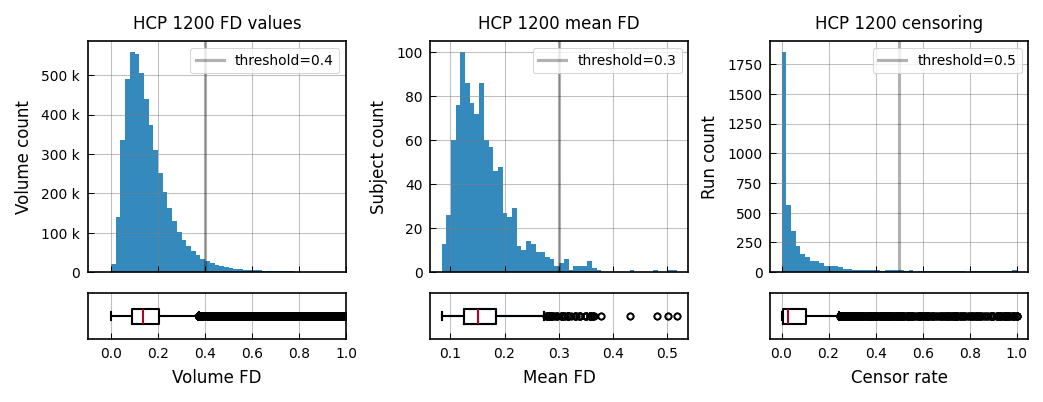

In [12]:
from matplotlib.ticker import EngFormatter

f, axs = plt.subplots(
    2,
    3,
    gridspec_kw={"height_ratios": [1.0, 0.2]},
    figsize=(2 * PLOTW, 0.75 * PLOTW),
    layout="constrained",
    sharex="col",
)

# Per-volume FD
plt.sca(axs[0, 0])
plt.hist(hcp_all_fd_values, bins=50, range=(0.0, 1.0))
plt.axvline(
    fd_spike_threshold, color="k", alpha=0.3, label=f"threshold={fd_spike_threshold}"
)
plt.ylabel("Volume count")
plt.title("HCP 1200 FD values")
axs[0, 0].yaxis.set_major_formatter(EngFormatter())
plt.legend()

plt.sca(axs[1, 0])
plt.boxplot(hcp_all_fd_values, vert=False, widths=1 / 3)
plt.yticks([])
plt.xlim([-0.1, 1.0])
plt.xlabel("Volume FD")

# Subject level mean FD
plt.sca(axs[0, 1])
plt.hist(hcp_fd_grouped_full["mean_fd"], bins=50)
plt.axvline(
    mean_fd_threshold, color="k", alpha=0.3, label=f"threshold={mean_fd_threshold}"
)
plt.ylabel("Subject count")
plt.title("HCP 1200 mean FD")
plt.legend()

plt.sca(axs[1, 1])
hcp_fd_grouped_full.boxplot(column="mean_fd", vert=False, widths=1 / 3)
plt.boxplot(hcp_fd_grouped_full["mean_fd"], vert=False, widths=1 / 3)
plt.yticks([])
plt.xlabel("Mean FD")

# Run level censor rates
plt.sca(axs[0, 2])
plt.hist(hcp_fd["censor_frac"], bins=50)
plt.axvline(
    censor_threshold, color="k", alpha=0.3, label=f"threshold={censor_threshold}"
)
plt.ylabel("Run count")
plt.title("HCP 1200 censoring")
plt.legend()

plt.sca(axs[1, 2])
plt.boxplot(hcp_fd["censor_frac"], vert=False, widths=1 / 3)
plt.yticks([])
plt.xlabel("Censor rate")

plt.savefig(hcp_fd_dir / f"hcp_1200_rfmri_fd.{FORMAT}")